# Linear Regression Model

Linear regression is one of the most fundamental models in machine learning. Even though it is simple, it provides the foundation for understanding many more complex models. Learning linear regression helps build intuition about key concepts such as cost functions and gradient descent, while also giving practical insight into how machine learning algorithms work. Let's take a look at it!


## Use Cases

By now, you will most likely have already seen a linear regression line. If you work on a lot of excel graphs, or PowerBI dashboards, you have probably seen a regression button. But how does it work?

Well think of the regression model as a trendline. A trendline that has a slope w, and an offset b. The regression model can be used for:
- Predicting house prices
- Predicting temperature
- Predicting sales
- Predicting fuel consumption



In [48]:
#Let's start by importing some useful libraries:

import pandas as pd #The Excel equivalent for python
import numpy as np #This will make compute faster and works well with pandas
import matplotlib.pyplot as plt #To plot

## Linear Regression Formula

The function used for linear regression is expressed as: $$f_wb = wx+b$$
Recall that the equation for a line in a 2D space is represented by the equation $y = mx + b$.
In that formula: 
- $m$ is the slope
- $b$ is the bias (offset that shifts the line up or down)
- $x$ is the input feature
- $y$ will be our prediction!

In [98]:
x_data = np.array([152, 170, 192, 175, 195, 201, 162]) #Data of height of different people (males, cm)
y_data = np.array([159, 165, 190, 184, 200, 204, 165]) #Data of the weights of the same people (pounds)

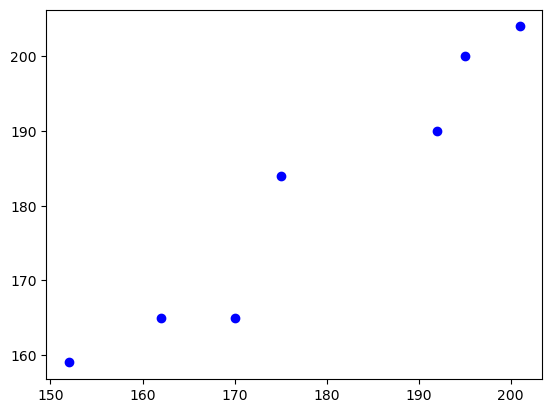

In [99]:
#Let's plot the data to visualize the correlation

plt.scatter(x_data, y_data, marker='o', color='b')
plt.show()

In [100]:
#m will be the number of rows we have, and n the number of features (We only have height, but we could also take gender, age, etc.
m = len(x_data)


## Cost Function

Think of this cost function as a penalty for the machine. If the line is not close to all points, it will calculate the closest distance from the points to the line, square it and then sum all the values. This means that if the line is so far away, the cost will have a HUGE value. But if it is close to all the points, the value will be minimized.

And that's what we want, minimize the cost function. 

It is represented as: $$J(\theta) = \frac{1}{2n} \sum_{i=1}^{m} \left( \hat{y}^{(i)} - y^{(i)} \right)^2$$

Where $\hat{y}^{(i)}$ is the $wx+b$ equation we saw earlier (we just change m for b since in ML, we use m for the number of rows in our data

In [101]:
#We can implement a cost function in code like this:

def cost_function(x, y, b, w, m):

    sum_cost = 0
    total_cost = 0

    for i in range(m):
        y_hat = w * x[i] + b
        instance_cost = (y_hat - y[i])**2
        sum_cost += instance_cost
        total_cost = (1/(2 * m)) * sum_cost
        
    return total_cost
    

## Gradient Descent

This is the key to train our model to be able to find the correct $w$ and $b$ values of our line!

Before I introduce you to gradient descent, we need to talk about the `hyperparameters`. These will be alpha (learning rate) and iterations (number of times to train). These two will be given by us, the user, and we will need to find the values that minimize compute cost and minimize our cost function the most. Starting with a small learning rate alpha will be key, since making it too big will lead to cost increasing instead of decreasing.

The explantion is a little bit complex, so let's just stick to the following gradient descent formulas:

Keep doing this x iterations:
$$w := w - \alpha \cdot \frac{\partial J}{\partial w}$$
$$b := b - \alpha \cdot \frac{\partial J}{\partial b}$$


Before we implement this function in code, lets implement another function that computes the partial derivatives in that function. The partial derivatives will be:

$$\frac{\partial J}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} \left( \hat{y}^{(i)} - y^{(i)} \right) \cdot x^{(i)}$$

$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} \left( \hat{y}^{(i)} - y^{(i)} \right)$$

Now, let's implement this in code

In [102]:
#Partial derivative calculator!
def compute_gradient(x, y, b, w, m):

    dj_dw = 0
    dj_db = 0

    for i in range(m):
        y_hat = w * x[i] + b

        dj_dw_i = (y_hat - y[i]) * x[i]
        dj_db_i = (y_hat - y[i])

        dj_dw += dj_dw_i
        dj_db += dj_db_i

    dj_dw = dj_dw/m
    dj_db = dj_db/m

    return dj_dw, dj_db

In [103]:
# Now that we implemented the function to get the partial derivatives, we can implement the whole gradient descent function
def gradient_descent(x, y, b, w, m, iterations, alpha):

    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(x, y, b, w, m)
        
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        if i % 100 == 0:
            cost = cost_function(x, y, b, w, m)
            print(f"Iteration: {i} Cost: {cost}")
    return b, w
        

In [118]:
#Initialize our hyperparameters and parameters:

alpha = 0.00006
iterations = 1000
w = 0
b = 0

In [119]:
#assign final values b and w:

b_final, w_final = gradient_descent(x_data, y_data, w, b, m, iterations, alpha)

Iteration: 0 Cost: 14029.832762718384
Iteration: 100 Cost: 10.594475061091638
Iteration: 200 Cost: 10.593313965937263
Iteration: 300 Cost: 10.593253660082532
Iteration: 400 Cost: 10.593193360831231
Iteration: 500 Cost: 10.593133068096156
Iteration: 600 Cost: 10.593072781876645
Iteration: 700 Cost: 10.59301250217198
Iteration: 800 Cost: 10.592952228981504
Iteration: 900 Cost: 10.592891962304419


In [120]:
#simple code to be able to plot the regression line (this just appends every single y value for each value x, and then appends it to a list)
y_pred = []

for i in range(m):
    y_pred.append(w_final * x_data[i] + b_final)

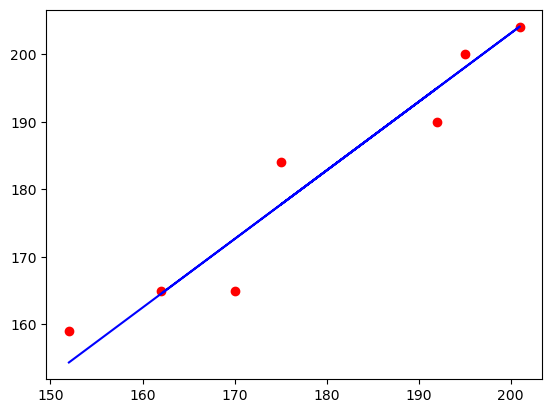

In [121]:
plt.scatter(x_data, y_data, marker='o', color='r', label='Datos Reales')
plt.plot(x_data, y_pred, color='b', label='Linea Regresion')
plt.show()


## Prediction

Now we can see after training, our linear regression model looks great! We may now implement code to predict a user input:


In [125]:
user_value = int(input("Enter the persons height, to predict the weight:"))

Enter the persons height, to predict the weight: 160


In [127]:
print(f"The predicted weight is: {(w_final * user_value + b_final):.2f} pounds")

The predicted weight is: 162.48 pounds


Thats it, we implemented a linear regression model from scratch!